# Application of Random Forest Algorithms for the Classification of Molecular Subtypes of Stomach Adenocarcinoma (TCGA-STAD)
## Multiclass vs. Binary Approach
**Luana da Silva do Aido** - Trackmodule 1 <br> Zurich University of Applied Science <br> Department of Applied Computational Life Science <br> January 2026 

## 1. Introduction
Stomach adenocarcinoma (STAD) is a biologically heterogeneous cancer. This means that tumors of the same clinical type can differ strongly at the molecular level. (Khanna et al., 2013)

Previous studies have shown that stomach cancer can be divided into distinct molecular subtypes. These subtypes are associated with differences in tumor biology. Prognosis and response to therapy. Correct identification of these subtypes is therefore essential. It plays an important role in cancer research and precision medicine. (Cancer Genome Atlas Research Network, 2014)

The major molecular subtypes include EBV-positive, microsatellite instable (MSI), genomically stable (GS), and chromosomal instability (CIN) tumors. Each subtype shows distinct genomic and biological characteristics. For example, MSI tumors have high mutation rates, while CIN tumors are characterized by extensive chromosomal alterations. EBV-positive tumors display strong immune signatures. GS tumors are associated with diffuse histology and poor prognosis. (Zhang, 2014)

Gene expression profiling enables the simultaneous measurement of thousands of genes. This provides detailed insight into tumor biology. (Goldenring & Nam, 2010)

Large public projects such as The Cancer Genome Atlas (TCGA) have generated comprehensive datasets. These include gene expression data together with molecular subtype labels for STAD. However, these datasets are highly dimensional. They contain expression values for thousands of genes, but only a limited number of tumor samples. This makes data analysis challenging and increases the risk of overfitting. (de Bodt et al., 2025)

Machine learning methods are well-suited for analyzing such high-dimensional biological data. Random Forest classifiers are particularly popular. They are robust, can model non-linear relationships, and perform well with large numbers of features. (Breiman, 2001)

Another advantage is that Random Forests provide feature importance scores. These can help identify genes relevant to subtype classification. (Wijaya, 2023)

In this project, molecular subtypes of STAD are classified using gene expression data from the TCGA-STAD cohort. Two classification strategies are compared. The first is a multiclass approach that distinguishes between all molecular subtypes. The second is a binary approach that separates tumors into microsatellite stable (MSS) and microsatellite instable (MSI) groups. The MSI group includes both MSI-L and MSI-H tumors. This comparison allows an evaluation of classification performance. It also shows how results differ between a simplified binary setting and a more biologically detailed multiclass scenario.


## 2. Setup
This section describes the initial data preparation steps, including library imports, dataset loading, data cleaning, and dataset preparation for multiclass and binary classification. These steps ensure data quality and establish a good foundation for the modelling process and further analysis.

### 2.1 Import libraries

The required libraries for data analysis, machine learning, and visualization were loaded. Additional tools were included for dimensionality reduction and data standardization.


In [154]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import *
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

### 2.2 Load the Datasets
Two datasets were loaded for the analysis. The first dataset contains gene expression profiles for Stomach Adenocarcinoma samples. The dataset contains 431 samples with 60616 gene features, representing high-dimensional molecular profiles. The second dataset includes clinical subtype information, providing CMS labels for each patient. 
These datasets were used together to link the gene expression pattern with corresponding cancer subtypes for subsequent modeling.

In [155]:
expression_df = pd.read_csv("/Users/luanadoaido/ZHAW/HS25/Track1/Mini Project/Track/Trackmodule_1_RF_TCGA-STAD/data/TCGA-STAD_gene_expression_cpm.csv", index_col=0)
# 431 rows und 60616 columns
print("Data shape Gene Expression:", expression_df.shape)

subtype_df = pd.read_csv("/Users/luanadoaido/ZHAW/HS25/Track1/Mini Project/Track/Trackmodule_1_RF_TCGA-STAD/TCGA-STAD_subtypes.csv", index_col=0)
print("Data shape Subtypes:", subtype_df.shape)
# 411 rows und 4 columns


Data shape Gene Expression: (431, 60616)
Data shape Subtypes: (411, 4)


### 2.3 Merge the Datasets
The two datasets were merged to link gene expression profiles with their corresponding CMS subtype labels for each patient.

In [156]:
#Are all ID's represented?
expr_ids = set(expression_df.index)
label_ids = set(subtype_df.index)

print(len(expr_ids))
print(len(label_ids))
print(len(expr_ids & label_ids))  # Overlapping samples
# as only 411 samples overlap the merged df will be smalller


431
411
411


In [157]:
#merging

cancer_df = pd.merge(subtype_df, expression_df, on="submitter_id", how="inner")
print("Data shape whole DF:", cancer_df.shape)
#411 rows und 60620 Columns

#print(cancer_df.head(10))

Data shape whole DF: (411, 60620)


After merging the two datasets, the final dataset contains 411 samples and 60620 features. The reduction in sample size indicates that not all patients were available in both sources. Only the samples with complete molecular and clinical information were retained for further analysis.

### 2.3 Data cleaning

#### 2.3.1 Missing values and duplicates
The dataset was screened for missing values and duplicates entries to ensure data quality prior to model training. This step is essential, as missing or repeated values can bias model performance and lead to unreliable predictions.

In [158]:
print("\nThere are", cancer_df.isna().sum().sum(), "Na's in the Dataframe.") #157

print("\nIn which features are the Na's present?\n", cancer_df.isna().sum().sort_values(ascending=False).head())
#there are 157 na

print("\nThere are", cancer_df.index.duplicated().sum(), "duplicated rows.")
#no duplicated rows
print("\nThere are", cancer_df.columns.duplicated().sum(), "duplicated Columns.")
#no duplicated columns




There are 157 Na's in the Dataframe.

In which features are the Na's present?
 Molecular.Subtype    137
MSI_phenotype         10
MSI_TMB               10
ENSG00000252494        0
ENSG00000252479        0
dtype: int64

There are 0 duplicated rows.

There are 0 duplicated Columns.


A total of 157 missing values were detected, primarily within selected clinical annotation features. No duplicated rows or columns were found. In the following steps the identified missing values were handled.
#### 2.3.2 Handling Categorical Variables
The dataset was inspected to identify categorical variables, as machine learning models require numerical input features. Non-numeric columns need either to be removed or transformed before model training. 


In [159]:
#cat variablen rausnehmen, verändern
cancer_df.select_dtypes(include="object").head()


,barcode_gene_expr,Molecular.Subtype,MSI_phenotype,MSI_TMB
submitter_id,,,,
TCGA-3M-AB46,TCGA-3M-AB46-01A-11R-A414-31,NaN,MSS,MSS/TMB-L
TCGA-3M-AB47,TCGA-3M-AB47-01A-22R-A414-31,NaN,MSI-L,MSS/TMB-L
TCGA-B7-5816,TCGA-B7-5816-01A-21R-1602-13,MSI,MSI-H,MSI-H
TCGA-B7-5818,TCGA-B7-5818-01A-11R-1602-13,EBV,MSI-L,MSS/TMB-L
TCGA-B7-A5TI,TCGA-B7-A5TI-01A-11R-A31P-31,NaN,MSI-H,MSI-H


Five categorical features were detected, including sample identifiers and clinical annotation variables such as molecular subtype and MSI-related variables. As the columns contain non-numeric values and missing entries, there needs to be some preprocessing done before modelling. 

All the gene expression features were numeric, indicating that they are directly compatible with the Random Forest model.

#### 2.3.3 Dataset Preparation for Binary and Multiclass Classification
Two separate datasets were created for both binary and multiclass classification approaches. This separation was necessary as each task requires a different target variable.
For the multiclass setting only the samples with available molecular subtype annotations were retained. Any Na's were dropped from the dataframe.
For the binary setting, samples with missing MSI phenotype information were excluded. To define a binary target variable, the MSI-L and MSI-H categories were combined into a single class labelled "MSI".

In [160]:
#as we have two different approaches we need to make two different Datasets which we need to clean
df_multi = cancer_df.dropna(subset=["Molecular.Subtype"]).copy()

print(df_multi["Molecular.Subtype"].value_counts())

df_binary = cancer_df.dropna(subset=["MSI_phenotype"]).copy()

df_binary["MSI_binary"] = df_binary["MSI_phenotype"].replace({
    "MSI-H": "MSI",
    "MSI-L": "MSI"
})

print(df_binary["MSI_binary"].value_counts())



Molecular.Subtype
CIN    136
MSI     59
GS      54
EBV     25
Name: count, dtype: int64
MSI_binary
MSS    265
MSI    136
Name: count, dtype: int64


The multi class dataset consists of four molecular subtypes (CIN, MSI, GS, EBV) with an imbalanced class distribution, where CIN represents the largest group (136 samples). EBV forms the smallest class with only 25 samples. 

The binary dataset was reduced to two classes, MSI and MSS, with almost double the amount of MSS samples. This confirms the presence of class imbalance in both classification setting. 

## 4. Preprocessing
This chapter covers all preprocessing steps applied before model training. It includes separating features and labels, exploratory analysis, dataset splitting, and feature filtering. These steps ensure that the data is clean, well-structured, and most importantly suitable for the Random Forest model.

### 4.1 Separating Features and Labels
For both classification tasks the dataset was separated into input features (X) and the target labels (y). This is required as ML models learn patterns from the input features in order to predict the corresponding target variables.

For the multiclass setting, the molecular subtype (CIN, MSI, GS, EBV) was defined as the targe variable. For the binary setting, the MSI status was used (MSI or MSS). All categorical columns were removed from the feature set to ensure that only numerical gene expression values were used for the model training, which is required by the Random Forest algorithm. 

In [161]:
#for the multi class approach
y_multi = df_multi["Molecular.Subtype"] #Targe Value
X_multi = df_multi.drop(columns=df_multi.select_dtypes(include="object").columns)

print(X_multi.dtypes.unique())   #should be only floeats


#for the binary class approach
y_binary = df_binary["MSI_binary"] #Targen value 2
X_binary = df_binary.drop(columns=df_binary.select_dtypes(include="object").columns)

print(X_binary.dtypes.unique())

[dtype('float64')]
[dtype('float64')]


To verify that the feature matrices (X) contain only gene expression data, the data types of all features were examined. The presence of exclusively floating-point values confirm that only numerical gene expression features are included. The target variables were successfully defined for both classification tasks, enabling the training of Random Forest models for multiclass and binary prediction.

### 4.2 Exploratory Data Analysis
Exploratory data analysis was preformed to gain an initial understanding of the dataset structure and class characteristics.

#### 4.2.1 Class Distribution

Firs, class distribution plots were generated for both settings to assess potential class imbalance. Understanding class proportions is essential, as imbalanced datasets can bias model training and evaluation.

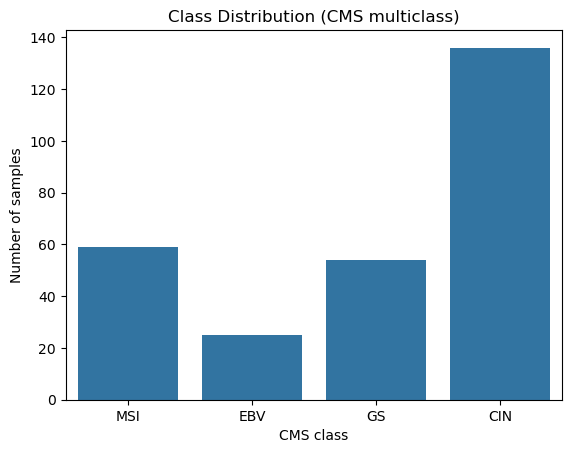

In [162]:
#Class Distribution
#multi class

plt.Figure()
sns.countplot(x= y_multi)
plt.title("Class Distribution (CMS multiclass)")
plt.xlabel("CMS class")
plt.ylabel("Number of samples")
plt.show()

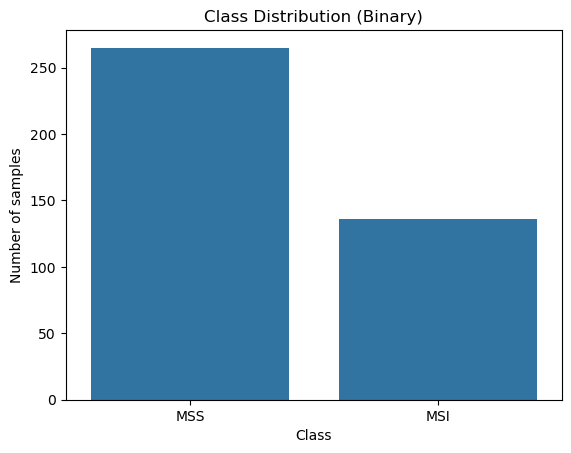

In [163]:
#binary

plt.Figure()
sns.countplot(x= y_binary)
plt.title("Class Distribution (Binary)")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.show()

The class distribution plot reveals an imbalanced class structure in both classification settings. In the multiclass scenario, the CIN represents the largest class, while EBV is the least represented subtype. MSI and GS are almost same represented. In the binary setting, the MSS samples are more frequent than MSI samples.

#### 4.2.2 Principal Component Analysis
A Principal Component Analysis (PCA) was applied to reduce the high-dimensional gene expression data to two components. This dimensionality reduction allows visual inspection of potential clustering patterns and class separability.

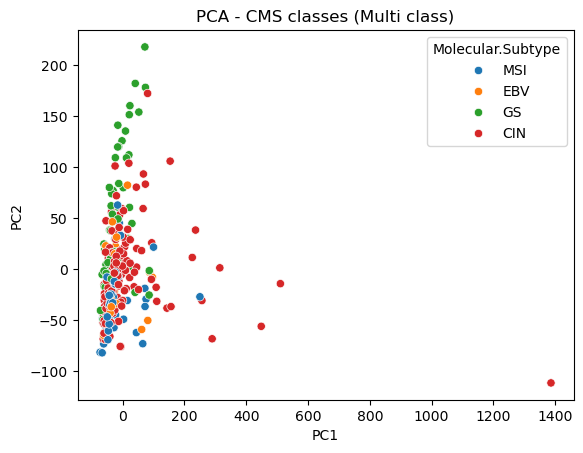

In [164]:
#PCA - Multi

scaler = StandardScaler()
X_scaled_multi = scaler.fit_transform(X_multi)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_scaled_multi)

plt.figure()
sns.scatterplot(x = x_pca[:,0], y= x_pca[:,1], hue = y_multi)
plt.title("PCA - CMS classes (Multi class)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


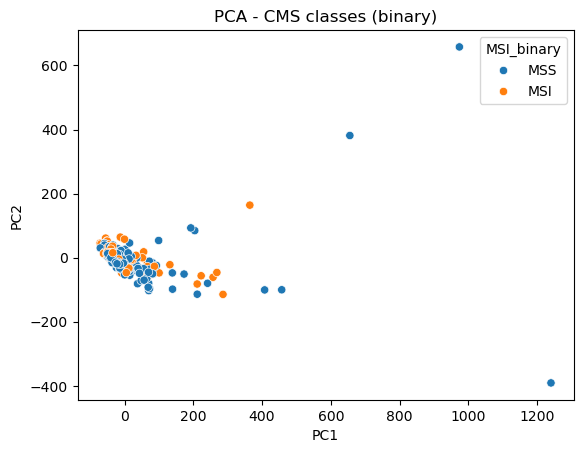

In [165]:
#PCA - binary

scaler = StandardScaler()
X_scaled_binary = scaler.fit_transform(X_binary)

pca = PCA(n_components=2)
x_pca_binary = pca.fit_transform(X_scaled_binary)

plt.figure()
sns.scatterplot(x = x_pca_binary[:,0], y= x_pca_binary[:,1], hue = y_binary)
plt.title("PCA - CMS classes (binary)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


The PCA visualizations show a substantial overlap between the classes, indicating limited linear separability of the subtypes. This ensured that the classification task is complex and may requires non-linear models such as Random Forest to capture underlying patterns.

#### 4.2.3 Correlation Heatmap
A correlation heatmap was created to analyze relationships between the most informative gene expression features.

The top features were selected based on their variance across all samples. Features with high variance show stronger expression differences between patients and are therefore more likely to contain relevant biological information for classification.

For the selected genes, pairwise correlation coefficients were calculated. These values measure the strength and direction of linear relationships. The heatmap visualizes these correlations, where warmer colors indicate strong positive correlation and cooler colors indicate negative correlation.

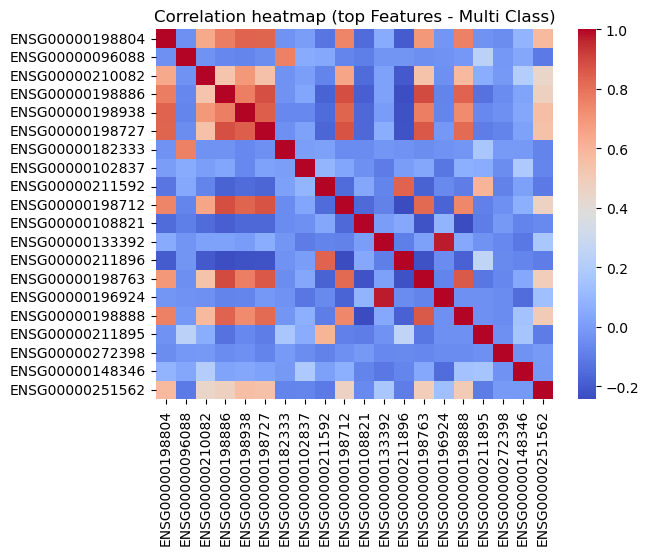

In [166]:
#heatmap with variance for multi
var_multi = X_multi.var()
top20_var = var_multi.sort_values(ascending=False).head(20)
feat_top = top20_var.index

#correlation Heatmap
plt.Figure(figsize=(10,8))
corr_multi = X_multi[feat_top].corr()
sns.heatmap(corr_multi, cmap = "coolwarm")
plt.title("Correlation heatmap (top Features - Multi Class)")
plt.show()

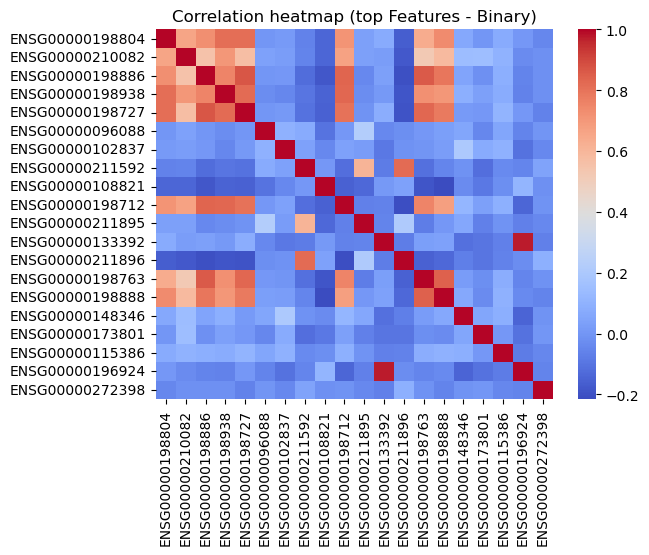

In [167]:
#heatmap with variance for multi
var_binary = X_binary.var()
top20_var_bin = var_binary.sort_values(ascending=False).head(20)
feat_top_bin = top20_var_bin.index

#correlation Heatmap
plt.Figure(figsize=(10,8))
corr_binary = X_binary[feat_top_bin].corr()
sns.heatmap(corr_binary, cmap = "coolwarm")
plt.title("Correlation heatmap (top Features - Binary)")
plt.show()

The heatmap reveals varying correlation patterns among the top high-variance genes. Some gene pairs show moderate to strong positive correlation. This suggests potential involvement in similar biological pathways.

At the same time, several features show weak or no correlation, indicating that they contribute independent information to the classification task.

### 4.3. Splitting into Training and Test sets
Separate train-test splits were performed for both the multiclass and binary datasets. A training proportion of 70% was chosen to provide sufficient data for model learning, while the remaining 30% was reserved for independent testing.


In [168]:
#for multi class approach
train_X_multi, test_X_multi, train_y_multi, test_y_multi = train_test_split(X_multi, y_multi, train_size= 0.7, random_state=1)

#for binary approach
train_X_binary, test_X_binary, train_y_binary, test_y_binary = train_test_split(X_binary, y_binary, train_size= 0.7, random_state=1)

The data was successfully split into training and test sets for both classification tasks.

### 4.3.1 Balanced Sets
After splitting the datasets into training and test sets, the class distributions were analyzed to verify whether both subsets remained representative of the original data.

This step is essential to ensure no class is over- or underrepresented. Imbalanced splits can bias model training and distort performance evaluation. The relative class proportion were therefore calculated for both the training and test sets in the multiclass and binary settings.

In [169]:
#testing if the target value in the testing and training set is balanced
train_y_multi = pd.Series(train_y_multi)
test_y_multi = pd.Series(test_y_multi)
print("\nTesting to see if the training and test set is balanced (multi):\n (Count in %)")
print("train:", train_y_multi.value_counts(normalize=True) * 100)
print("\ntest:", test_y_multi.value_counts(normalize=True) * 100)


train_y_binary = pd.Series(train_y_binary)
test_y_binary = pd.Series(test_y_binary)
print("\nTesting to see if the training and test set is balanced (binary):\n (Count in %)")
print("train:", train_y_binary.value_counts(normalize=True) * 100)
print("\ntest:", test_y_binary.value_counts(normalize=True) * 100)




Testing to see if the training and test set is balanced (multi):
 (Count in %)
train: Molecular.Subtype
CIN    51.832461
MSI    20.418848
GS     19.895288
EBV     7.853403
Name: proportion, dtype: float64

test: Molecular.Subtype
CIN    44.578313
MSI    24.096386
GS     19.277108
EBV    12.048193
Name: proportion, dtype: float64

Testing to see if the training and test set is balanced (binary):
 (Count in %)
train: MSI_binary
MSS    65.0
MSI    35.0
Name: proportion, dtype: float64

test: MSI_binary
MSS    68.595041
MSI    31.404959
Name: proportion, dtype: float64


The results show that class proportion are comparable between the training and test sets for boh classification tasks. In the multiclass setting, as in the binary setting, the ratio between the subtypes remains consistent between training and test data. This confirms that the splitting strategy preserved the original class structure.

The target distribution in the dataset is not perfectly balanced but all classes are sufficiently represented. Moderate class imbalance is common in biological and clinical datasets and does not compromise the validation of supervised learning approaches. As long as each class contains an adequate number of samples, meaningful patterns can still be learned and evaluated.


### 4.4 Feature Filtering
Due to the high dimensionality of the gene expression data, a two-step feature filtering strategy was applied. Feature filtering is applied only to the feature matrix (X) and not to the target variable (y) because filtering aims to remove uninformative input features, not class labels.

A low-expression Filter was used to remove genes that are expressed in only a small fraction of samples. Genes that are rarely expressed across patients are unlikely to provide meaningful information for classification.

Afterwards, a variance-based filtering was applied to remove features with low variance. Features with low variance show little change across samples and therefore contribute limited discriminatory information. Removing these helps the model to focus on more informative genes and reduces computational complexity.

Feature filtering was learned exclusively from the training data. The same selected features were then applied to the test set to avoid information leakage and ensure unbiased evaluation.

#### 4.4.1 Low-Expression Filter
A low-expression Filter was applied to remove genes that are not sufficiently expressed across samples. A gene was retained only if it showed non-zero expression values in at least 10% of the training samples. This threshold ensures that only genes with consistent expression patterns across multiple patients are kept. (RNASeq Filtering, n.d.)


In [170]:
#for Multiclass Target - filter machen
min_samples_multi = int(0.1 *train_X_multi.shape[0])

#das eigentliche
mask_multi = (train_X_multi > 0).sum(axis=0) >= min_samples_multi

#Anwenden
X_train_multi_filt = train_X_multi.loc[:, mask_multi]
X_test_multi_filt = test_X_multi.loc[:, mask_multi]


In [171]:
#for Binary Target - filter machen
min_samples_binary = int(0.1 *train_X_binary.shape[0])

#das eigentliche
mask_binary = (train_X_binary > 0).sum(axis=0) >= min_samples_binary

#Anwenden
X_train_binary_filt = train_X_binary.loc[:, mask_binary]
X_test_binary_filt = test_X_binary.loc[:, mask_binary]

After applying the low-expression filter, genes with sparse expression patterns were successfully removed from the dataset. This step reduces dimensionality while preserving genes that show consistent expressions across patients. This results in a cleaner and more informative dataset for modelling.

#### 4.4.2 Variance Threshold
Variance-based feature filtering was applied to further reduce dimensionality. Genes with very low variability across the samples were removed by this step.

A variance threshold of 0.01 was selected to exclude features with minimal variation. Genes with extremely low variance are nearly constant across all samples and therefore do not contribute meaningful discriminatory information for classification.

In [172]:
vt_multi = VarianceThreshold(threshold=0.01)
vt_multi.fit(X_train_multi_filt)

selected_genes_multi = X_train_multi_filt.columns[vt_multi.get_support()]

X_train_var_multi = X_train_multi_filt[selected_genes_multi]
X_test_var_multi  = X_test_multi_filt[selected_genes_multi]


vt_binary = VarianceThreshold(threshold=0.01)
vt_binary.fit(X_train_binary_filt)

selected_genes_binary = X_train_binary_filt.columns[vt_binary.get_support()]

X_train_var_binary = X_train_binary_filt[selected_genes_binary]
X_test_var_binary  = X_test_binary_filt[selected_genes_binary]


The variance-based feature filtering successfully removed low-variability genes from both datasets. As a result, the final feature sets contain genes with higher variability, which are more likely to capture biologically relevant differences between the classes. 

In [173]:
print(X_train_var_multi.shape[1],
X_test_var_multi.shape[1],
X_train_var_binary.shape[1],
X_test_var_binary.shape[1])

33597 33597 32392 32392



After both filtering steps, the dimensionality of the datasets was reduced. For the multiclass setting, the number of features decreased to 33597 genes for both the training and test sets. In the binary setting (training and test set), 32392 features remained after filtering.

This represents a considerable reduction from the original feature space and demonstrated the effectiveness of the filtering strategy in removing non-informative genes.

## 5. Modelling
In this chapter, Random Forest models were optimized and trained for both multiclass and binary classification. Hyperparameter tuning was performed to identify optimal model settings and reduce overfitting. The final models were trained exclusively on th training data. 

### 5.1 Hyperparameter Tuning
Hyperparameter tuning was performed for both the multiclass and binary classification tasks to optimes the Random Forest models. A grid search approach combined with cross-validation was used to systematically evaluate different parameter combinations. The tested parameters included the number of trees (n_estimators), maximum tree depth (max_depth), and the minimum number of samples per leaf (min_samples_leaf).

The parameter max_features was fixed to square root (sqrt) of the total number of features to reduce computational cost. Testing additional values would significantly increase runtime due to the very high number of input features. Using sqrt is a common and well-established default for Random Forests.

Macro-averaged F1 score was chosen as the evaluation metric to ensure balanced performance across all classes, especially in the presence of class imbalance.

In [174]:
#Multi
param_grid_multi = {
    "n_estimators": [100, 300],
    "max_depth": [None, 20, 50, 100],
    "max_features": ["sqrt"],
    "min_samples_leaf": [1,2,5, 10]
}

rf_multi = RandomForestClassifier(random_state=42)
grid_mulit = GridSearchCV(rf_multi, param_grid_multi, cv=3, scoring="f1_macro")
grid_mulit.fit(X_train_var_multi , train_y_multi)

print("Best parameters:", grid_mulit.best_params_)
print("Best CV score:", grid_mulit.best_score_)


Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
Best CV score: 0.6996234424823499


For the multiclass model, the best performing configuration used 300 trees, unlimited tree depth, and a minimum of two samples per leaf. This resulted in a cross validated F1-macro score of approximately 0.70. This implies that around 70% of the model's positive predictions are correct while a similar proportion of true positive cases are successfully identified.

In [175]:
#binary
param_grid_binary = {
    "n_estimators": [100, 300],
    "max_depth": [None, 20, 50, 100],
    "max_features": ["sqrt"],
    "min_samples_leaf": [1,2,5, 10]
}

rf_binary = RandomForestClassifier(random_state=42)
grid_binary = GridSearchCV(rf_binary, param_grid_binary, cv=3, scoring="f1_macro")
grid_binary.fit(X_train_var_binary , train_y_binary)

print("Best parameters:", grid_binary.best_params_)
print("Best CV score:", grid_binary.best_score_)

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
Best CV score: 0.7551081680434915


For the binary model, the optimal setup selected 100 trees with the same remaining parameters values, achieving a higher F1-macro score of approximately 0.76.

These results indicate better separability for the binary tasks compared to the multiclass setting.


### 5.2 Train the Random Forest Model
After selecting the optimal hyperparameters, the final Random Forest models were trained separately for the multiclass and binary datasets using the filtered training features. The models were fitted exclusively on the training data to avoid data leakage and ensure unbiased evaluation on the test set.

In [176]:
rfc_multi = RandomForestClassifier(n_estimators=300, bootstrap=True, min_samples_leaf= 2, max_depth=None, max_features='sqrt', criterion='gini', random_state=42)
rfc_multi.fit(X_train_var_multi , train_y_multi)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [177]:
rfc_binary = RandomForestClassifier(n_estimators=100, bootstrap=True, max_depth=None, max_features='sqrt', min_samples_leaf=10, criterion='gini', random_state=42)
rfc_binary.fit(X_train_var_binary , train_y_binary)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


This completes the model training step for both classification tasks.

## 6. Evaluation of model performance
This chapter evaluates the performance of the trained Random Forest models on unseen test data. Standard classification metrics were used to s predictive quality. The results are reported separately for the multiclass and binary approaches to enable a structured comparison of model behavior.

### 6.1 Multiclass approach
#### 6.1.1 Prediction and calculation
The trained Random Forest model was applied to the unseen test set to generate class predictions. Model performance was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. These metrics provide complementary insights into classification quality across all classes.

In [178]:
#Predicting
y_pred_multi = rfc_multi.predict(X_test_var_multi)

#metrics
#accuracy score
print("Accuracy of multi class RF:", accuracy_score(test_y_multi, y_pred_multi))
print(classification_report(test_y_multi, y_pred_multi))

Accuracy of multi class RF: 0.7349397590361446
              precision    recall  f1-score   support

         CIN       0.67      0.92      0.77        37
         EBV       1.00      0.30      0.46        10
          GS       0.71      0.62      0.67        16
         MSI       0.93      0.70      0.80        20

    accuracy                           0.73        83
   macro avg       0.83      0.64      0.68        83
weighted avg       0.78      0.73      0.72        83



The model achieved on overall accuracy of 0.73, meaning 73% of samples were classified correctly. The classification report shows strong performance for the MSI and CIN classes, while EBV shows lower recall due to its small sample size. This indicates that class imbalance affects prediction reliability for rare cases like EBV.

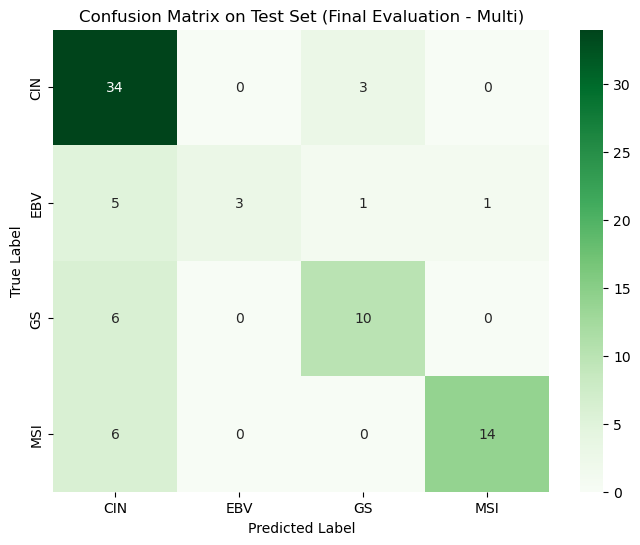

In [179]:
#Confusionmatrix:
multi_test = confusion_matrix(test_y_multi, y_pred_multi)

plt.figure(figsize=(8, 6))
sns.heatmap(multi_test, annot=True, fmt="d", cmap='Greens',
            xticklabels=rfc_multi.classes_,
            yticklabels=rfc_multi.classes_)
plt.title('Confusion Matrix on Test Set (Final Evaluation - Multi)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

The confusion matrix was computed to visualize true versus predicted class labels. This allows identification of systematic misclassifications. Most samples are correctly classified along the diagonal. Misclassifications mainly occur between CIN and GS/MSI classes, indicating partial overlap in gene expression patterns. EBV shows the highest confusion, which is expected due to its limited sample size.

#### 6.1.2 Feature importance
Feature importance was extracted from the trained Random Forest model to identify which genes contributed most to the classification. Random Forest calculates importance based on how much each feature reduces impurity across all decision trees. The features were ranked and the top 10 most influential genes were selected for visualization.

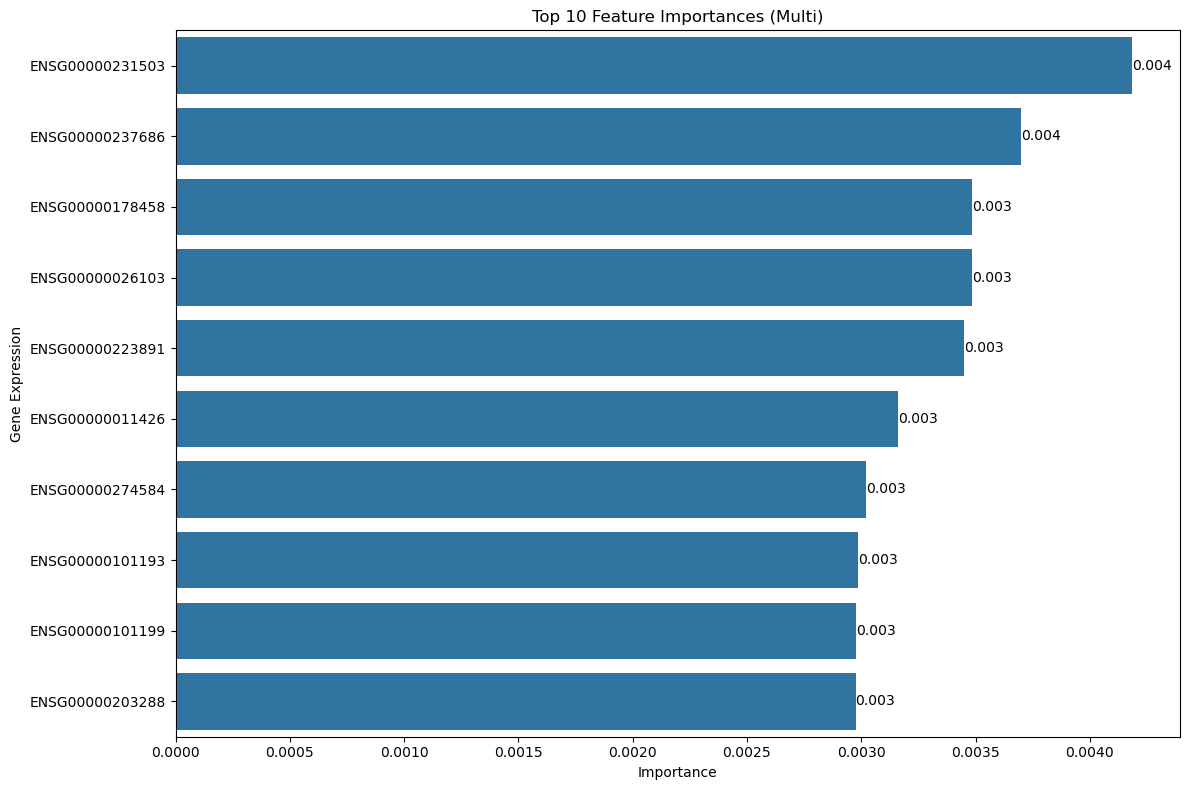

In [180]:
# Feature importance
feature_importance_multi = pd.DataFrame({
    "feature": X_test_var_multi.columns,
    "importance": rfc_multi.feature_importances_
}).sort_values("importance", ascending=False)

top10_multi = feature_importance_multi.head(10)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_multi.head(10), x="importance", y="feature", orient="h")
plt.title("Top 10 Feature Importances (Multi)")
plt.xlabel("Importance")
plt.ylabel("Gene Expression")

for i, (imp, feat) in enumerate(zip(top10_multi["importance"], top10_multi["feature"])):
    plt.text(
        imp - 0.0002 * max(top10_multi["importance"]),
        i,
        f"{imp:.3f}",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()

The plot shows the ten genes with the highest importance score. These genes have the strongest impact on the model's prediction. Although the absolute importance values are small, this is expected due to the high number of features. The ranking highlights potential biologically relevant genes that drive subtype discrimination.

### 6.2 Binary approach
#### 6.2.1 Prediction and calculation
The same evaluation metric as used for the multiclass approach were applied to the binary classification setting. This ensures methodological consistency and allows a direct comparison between both classification strategies. To further evaluate the binary classifier, a ROC curve was generated using the predicted class probabilities. 



In [181]:
#Predicting
y_pred_binary = rfc_binary.predict(X_test_var_binary)

#metrics
#accuracy score
print("Accuracy of Binary class RF:", accuracy_score(test_y_binary, y_pred_binary))
print(classification_report(test_y_binary, y_pred_binary))


Accuracy of Binary class RF: 0.7768595041322314
              precision    recall  f1-score   support

         MSI       0.79      0.39      0.53        38
         MSS       0.77      0.95      0.85        83

    accuracy                           0.78       121
   macro avg       0.78      0.67      0.69       121
weighted avg       0.78      0.78      0.75       121



The model achieved an accuracy of 0.78 on the test set. MSS samples were classified very well (recall = 0.95), while MSI samples showed lower recall (0.39), indicating that many MSI cases were misclassified as MSS. The weighted F1-score of 0.75 reflects good overall performance but also highlights class imbalance effects, with stronger performance on the MSS class.

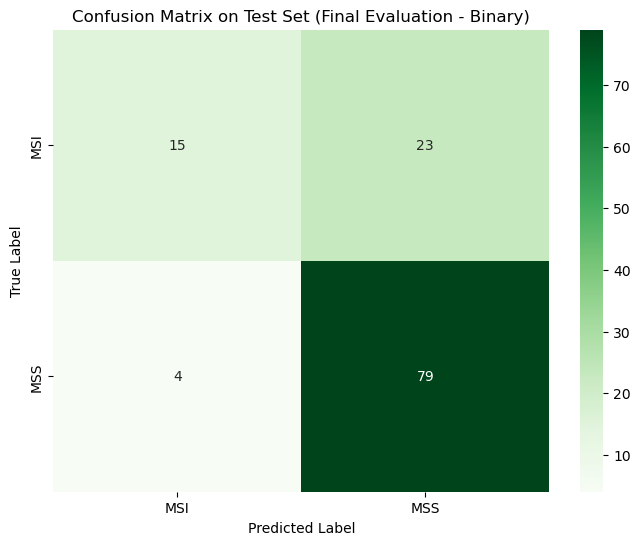

In [182]:
#Confusionmatrix:
binary_test = confusion_matrix(test_y_binary, y_pred_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(binary_test, annot=True, fmt="d", cmap="Greens",
            xticklabels=rfc_binary.classes_,
            yticklabels=rfc_binary.classes_)


plt.title("Confusion Matrix on Test Set (Final Evaluation - Binary)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

The matrix compares the true class labels (MSI, MSS) with the predicted labels. Allowing identification of correct prediction and specific misclassification patterns. The model correctly classified 79 MSS and 15 MSI samples. However, 23 MSI samples were misclassified as MSS. This indicates reduced sensitivity for detecting MSI cases. As only 4 MSS samples were wrongly predicted, it shows that the model biased toward the MSS class and struggles to correctly identify MSI cases. 

ROC-AUC Value: 0.16582117945466077


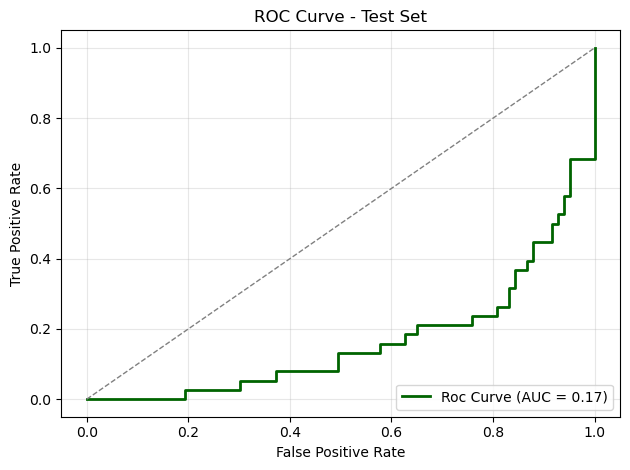

In [183]:
#ROC-AUC
#predict probabilities for MSS
test_prob_binary = rfc_binary.predict_proba(X_test_var_binary)[:,1] #for posiive variable MSI
fpr_binary, tpr_binary, thresholds = roc_curve(test_y_binary, test_prob_binary, pos_label="MSI")
roc_auc_binary = auc(fpr_binary,tpr_binary)
print("ROC-AUC Value:", roc_auc_binary)
#Roc curve visualization:

plt.Figure(figsize=(8,6))
plt.plot(fpr_binary,tpr_binary, color ="darkgreen", lw = 2,
         label=f"Roc Curve (AUC = {roc_auc_binary:.2f})")

plt.plot([0,1],[0,1], color = "gray", lw= 1, linestyle = "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Test Set")
plt.legend(loc = "lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The ROC curve illustrates the trade-off between the true positive rate and the false positive rate across different decision thresholds. The Area Under the Curve (AUC) was calculated as a summary measure of the model's discriminative ability. The model achieved an AUC value of almost 0.17, which is substantially below 0.5. This indicates that the classifier performs worse than random guessing when distinguishing between MSI and MSS samples. The ROC curve lies mostly below the diagonal reference line, confirming poor separability between the two classes. This suggests, that despite acceptable accuracy, the probability outputs of the model are not reliable for ranking MSI vs MSS cases.

### 6.2.2 Feature importance

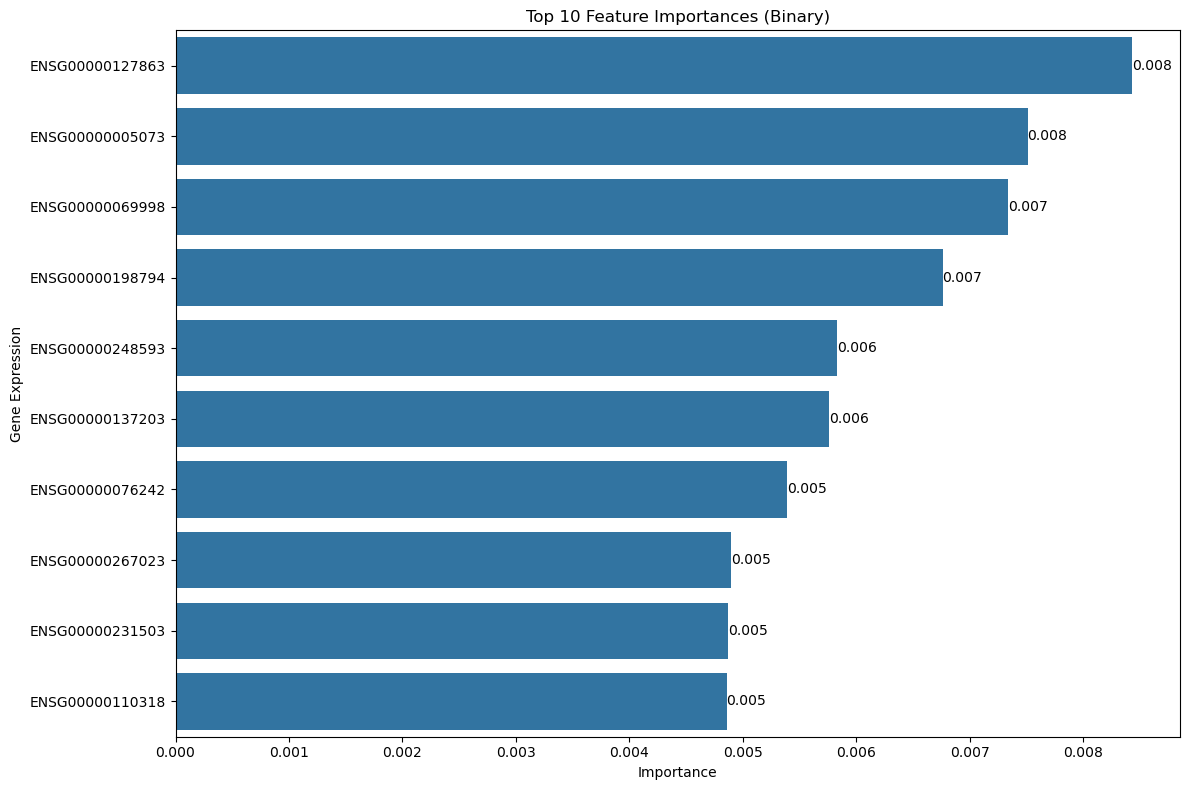

In [184]:
# Feature importance
feature_importance_binary = pd.DataFrame({
    "feature": X_test_var_binary.columns,
    "importance": rfc_binary.feature_importances_
}).sort_values("importance", ascending=False)


top10_binary = feature_importance_binary.head(10)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_binary.head(10), x="importance", y="feature", orient="h")
plt.title("Top 10 Feature Importances (Binary)")
plt.xlabel("Importance")
plt.ylabel("Gene Expression")

for i, (imp, feat) in enumerate(zip(top10_binary["importance"], top10_binary["feature"])):
    plt.text(
        imp - 0.0002 * max(top10_binary["importance"]),
        i,
        f"{imp:.3f}",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()

This project also shows the ten genes with the highest importance scores. Although these features contributed most to the model's decisions, the absolute importance values remain relatively low and close to each other. This indicates that no single gene strongly dominates the classification. Given the weak ROC-AUC performance, these importance scores should be interpreted cautiously, as the overall discriminative power of the model is limited.

## 7. Discussion
This project compared multiclass and binary Random Forest classification on the stomach adenocarcinoma gene expression dataset. The multiclass model demonstrated moderate but consistent performance across the four molecular subtypes. Accuracy and class-specific F1-scores indicated that the model could distinguish among most subtypes, although performance varied by class size. This suggests that gene expression profiles contain subtype-specific patterns that can be captured by Random Forest models (Khanna et al., 2013).

A major reason for this weak performance is the merging of MSI-L and MSI-H into a single MSI class. While both are microsatellite instable, they differ biologically. MSI-H tumors show strong genomic instability, whereas MSI-L samples are more heterogeneous and closer to MSS at the molecular level. Combining them introduced noise into the MSI class. This made it difficult for the model to learn a clear separation. (de la Chapelle & Hampel, 2010; Han et al., 2022)

In contrast, the binary classifier showed weaker discriminative performance. Although the overall accuracy appears acceptable (~0.78), the ROC-AUC value of 0.17 indicates extremely poor class separation. This highlights that accuracy alone is insufficient to evaluate model quality, particularly in imbalanced datasets. The model tended to favor the majority MSS class, resulting in reduced sensitivity for MSI detection. The project demonstrated the importance of using multiple evaluation metrics (Mamalakis et al., 2024). While accuracy provided a general performance overview, precision, recall, F1-scores, confusion matrices, and ROC-AUC revealed class-specific weaknesses that accuracy alone masked. Especially in clinical Settings, ROC-AUC is essential as it evaluates threshold-independent class discrimination (Verbakel et al., 2020).

Feature importance analysis also showed that prediction is driven by multiple genes rather than by a single dominant marker. This indicated that no individual gene alone is sufficient to distinguish between the subtypes. Instead, a combination of several genetic features contributes to the model’s decision-making process. His findings reflect the complex molecular profiles of the subtypes and support the idea that these conditions are influenced by interacting biological pathways rather than isolated factors. (Ramadhani et al., 2025)

Several limitations of this project should be considered. The dataset contains class imbalance and a small sample size for some subtypes. This may bias model performance and reduce reliability for minority classes (Zhao et al., 2025). In addition, merging MSI-L and MSI-H into a single MSI class introduces biological heterogeneity and reduces class separability (Han et al., 2022). Finally, the model was only validated internally on the same dataset and not tested on an independent dataset from a different source. As a result, it remains unclear how well the model would perform on another dataset. Future work should keep MSI-L and MSI-H as separate classes. Treating them separately would allow the models to capture more detailed patterns. Including larger and independent datasets would increase the robustness of the results. It would also improve generalizability and reduce the risk of overfitting. Advanced feature selection methods should be explored. They can help identify the most informative biomarkers and reduce noise in the data. This may improve interpretability. Finally, integrating clinical variables could further improve prediction performance. Variables such as age, tumor stage, and treatment history provide important information.

Overall, the multiclass approach preserved biological differences better and clearly outperformed the binary model. These findings stress the importance of biologically meaningful class definitions and appropriate evaluation metric in clinical machine learning applications.


## References
Baladram, S. (2024, November 30). Random Forest, Explained: A Visual Guide with Code Examples. TDS Archive. https://medium.com/data-science/random-forest-explained-a-visual-guide-with-code-examples-9f736a6e1b3c

Basher, A. R. M. A., Hallinan, C., & Lee, K. (2025). Heterogeneity-Preserving Discriminative Feature Selection for Disease-Specific Subtype Discovery. bioRxiv, 2023.05.14.540686. https://doi.org/10.1101/2023.05.14.540686

Breiman, L. (2001). Random Forests. Mach. Learn., 45(1), 5–32. https://doi.org/10.1023/A:1010933404324
Cancer Genome Atlas Research Network. (2014). Comprehensive molecular characterization of gastric adenocarcinoma. Nature, 513(7517), 202–209. https://doi.org/10.1038/nature13480

Çorbacıoğlu, Ş. K., & Aksel, G. (2023). Receiver operating characteristic curve analysis in diagnostic accuracy studies: A guide to interpreting the area under the curve value. Turkish Journal of Emergency Medicine, 23(4), 195–198. https://doi.org/10.4103/tjem.tjem_182_23

de Bodt, C., Diaz-Papkovich, A., Bleher, M., Bunte, K., Coupette, C., Damrich, S., Sanmartin, E. F., Hamprecht, F. A., Horvát, E.-Á., Kohli, D., Krishnaswamy, S., Lee, J. A., Lelieveldt, B. P. F., McInnes, L., Nabney, I. T., Noichl, M., Poličar, P. G., Rieck, B., Wolf, G., … Kobak, D. (2025). Low-dimensional embeddings of high-dimensional data. https://arxiv.org/html/2508.15929v1

de la Chapelle, A., & Hampel, H. (2010). Clinical Relevance of Microsatellite Instability in Colorectal Cancer. Journal of Clinical Oncology, 28(20), 3380–3387. https://doi.org/10.1200/JCO.2009.27.0652

Goldenring, J. R., & Nam, K. T. (2010). Oxyntic Atrophy, Metaplasia, and Gastric Cancer. In Progress in Molecular Biology and Translational Science (Vol. 96, pp. 117–131). Academic Press. https://doi.org/10.1016/B978-0-12-381280-3.00005-1

Gulati, P., Sharma, A., & Gupta, M. (2016). Theoretical Study of Decision Tree Algorithms to Identify Pivotal Factors for Performance Improvement: A Review. International Journal of Computer Applications, 141(14), 19–25. https://doi.org/10.5120/ijca2016909926

Han, S., Chok, A. Y., Peh, D. Y. Y., Ho, J. Z.-M., Tan, E. K. W., Koo, S.-L., Tan, I. B.-H., & Ong, J. C.-A. (2022). The distinct clinical trajectory, metastatic sites, and immunobiology of microsatellite-instability-high cancers. Frontiers in Genetics, 13, 933475. https://doi.org/10.3389/fgene.2022.933475

Khanna, C., Avery, A. C., Olver, C., & Paoloni, M. C. (2013). Molecular Diagnostics. In Withrow and MacEwen’s Small Animal Clinical Oncology (pp. 131–142). W.B. Saunders. https://doi.org/10.1016/B978-1-4377-2362-5.00008-6

Mamalakis, M., Banerjee, A., Ray, S., Wilkie, C., Clayton, R. H., Swift, A. J., Panoutsos, G., & Vorselaars, B. (2024). Deep multi-metric training: The need of multi-metric curve evaluation to avoid weak learning. Neural Computing and Applications, 36(30), 18841–18862. https://doi.org/10.1007/s00521-024-10182-6

Ramadhani, S., Handayani, L., Ng, T., Dzulkifly, S., Ariffin, R., Budiman, H., & Wang, S. (2025). Feature Selection Optimisation for Cancer Classification Based on Evolutionary Algorithms: An Extensive Review. Computer Modeling in Engineering & Sciences, 143(3), 2711–2765. https://doi.org/10.32604/cmes.2025.062709

RNASeq filtering. (n.d.). Retrieved January 10, 2026, from https://combine-australia.github.io/RNAseq-R/slides/RNASeq_filtering_qc.pdf

Sha, Y., Phan, J. H., & Wang, M. D. (2015). Effect of low-expression gene filtering on detection of differentially expressed genes in RNA-seq data. Conference Proceedings : ... Annual International Conference of the IEEE Engineering in Medicine and Biology Society. IEEE Engineering in Medicine and Biology Society. Annual Conference, 2015, 6461–6464. https://doi.org/10.1109/EMBC.2015.7319872 

Verbakel, J. Y., Steyerberg, E. W., Uno, H., De Cock, B., Wynants, L., Collins, G. S., & Van Calster, B. (2020). ROC curves for clinical prediction models part 1. ROC plots showed no added value above the AUC when evaluating the performance of clinical prediction models. Journal of Clinical Epidemiology, 126, 207–216. https://doi.org/10.1016/j.jclinepi.2020.01.028

Wijaya, C. Y. (2023, December 16). Random Forest Feature Importance Explained. https://www.nb-data.com/p/random-forest-feature-importance

Zhang, W. (2014). TCGA divides gastric cancer into four molecular subtypes: Implications for individualized therapeutics. Chinese Journal of Cancer, 33(10), 469–470. https://doi.org/10.5732/cjc.014.10117

Zhao, S., Gui, J., Dong, M., Yu, B., Gui, Z., Dong, L., Tang, Y. Y., & Kwok, J. T.-Y. (2025). A Survey on Small Sample Imbalance Problem: Metrics, Feature Analysis, and Solutions. https://arxiv.org/html/2504.14800v1








## Use of AI
AI tools were used to clarify questions and to support understanding of concepts before starting the project. Furthermore, AI was used for code debugging and for improving English grammar and clarity. All analytical decisions, interpretations, and conclusions were made independently by the author.